###### !pip install opencv-python

In [1]:
#!pip install opencv-python
#!pip install pandas

In [4]:
!pip install opencv-python
!pip show opencv-python

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   - -------------------------------------- 1.0/39.0 MB 6.3 MB/s eta 0:00:07
   -- ------------------------------------- 2.4/39.0 MB 5.8 MB/s eta 0:00:07
   --- ------------------------------------ 3.4/39.0 MB 5.8 MB/s eta 0:00:07
   ---- ----------------------------------- 4.7/39.0 MB 5.8 MB/s eta 0:00:06
   ----- ---------------------------------- 5.8/39.0 MB 5.8 MB/s eta 0:00:06
   ------- -------------------------------- 7.1/39.0 MB 5.7 MB/s eta 0:00:06
   -------- ------------------------------- 8.4/39.0 MB 5.8 MB/s eta 0:00:06
   --------- ------------------------------ 9.4/39.0 MB 5.8 MB/s eta 0:00:06
   ----------- ---------------------------- 10.7/39.0 MB 5.7 MB/s eta 0:00:05
   ------------ --------------------------- 11.8/39.0 MB 5.7 MB/s eta 0:00:05
   ------------- -------------------------- 13.1/39.0 MB 5.7 MB/s eta 0:00:05
   -------

  You can safely remove it manually.
  You can safely remove it manually.


Name: opencv-python
Version: 4.12.0.88
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: c:\users\maria\anaconda3\envs\tf_gpu\lib\site-packages
Requires: numpy
Required-by: 


In [8]:
!pip install numpy==1.26.4 scipy==1.11.4 scikit-learn==1.4.2 opencv-python==4.8.1.78 --force-reinstall

  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
  Using cached scipy-1.11.4-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.4.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
Using cached scipy-1.11.4-cp310-cp310-win_amd64.whl (44.1 MB)
Using cached scikit_learn-1.4.2-cp310-cp310-win_amd64.whl (10.6 MB)
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.1 MB 5.6 MB/s eta 0:00:07
   -- ------------------------------------- 2.4/38.1 MB 5.6 MB/s eta 0:00:07
   --- ------------------------------------ 3.4/38.1 MB 5.6 MB/s eta 0:00:07
   ---- ----------------------------------- 4.7/38.1 MB 5.7 MB/s eta 0:00:06
   ------ --------------------------------- 6.0/38.1 MB 5.7 MB/s eta 0:00:06
  

  You can safely remove it manually.


In [10]:
!pip uninstall scipy -y
!pip install scipy==1.11.4 --force-reinstall


Found existing installation: scipy 1.11.4
Uninstalling scipy-1.11.4:
  Successfully uninstalled scipy-1.11.4


You can safely remove it manually.
You can safely remove it manually.


  Using cached scipy-1.11.4-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
Using cached scipy-1.11.4-cp310-cp310-win_amd64.whl (44.1 MB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 1.26.4

   ---------------------------------------- 0/2 [numpy]
    Uninstalling numpy-1.26.4:
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
      Successfully uninstalled numpy-1.26.4
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   -----------------

In [1]:
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import cv2
import numpy as np
from glob import glob
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers
from tensorflow import keras 
import tensorflow as tf

In [2]:
import glob
import pandas as pd
from PIL import Image
import numpy as np

def process_images(path, label, group_name, df, counter, images, targets, load_img):
    for ext in ["*.png", "*.webp", "*.jpg"]:
        for filename in glob.glob(path + ext, recursive=True):
            images.append(filename)
            df.loc[counter, 'img_path'] = filename
            df.loc[counter, group_name] = label
            counter += 1
            img = Image.open(filename)
            img = img.resize((256, 256))
            if img is not None:
                rgb = img.convert('RGB')
                if rgb is not None:
                    targets.append(1 if label == 'true' else 0)
                    load_img.append(np.array(rgb))
    return counter

def load(path_true, path_false, group_name, df, counter):
    images, targets, load_img = [], [], []
    
    # Process true images
    counter = process_images(path_true, 'true', group_name, df, counter, images, targets, load_img)
    number_images_true = len(images)
    
    # Process false images
    counter = process_images(path_false, 'false', group_name, df, counter, images, targets, load_img)
    number_images_false = len(images) - number_images_true
    
    return number_images_true, number_images_false, images, targets, load_img, counter

# Example usage:
# df = pd.DataFrame()
# counter = 0
# number_images_true, number_images_false, images, targets, load_img, counter = load("path/to/true/", "path/to/false/", "group_name", df, counter)



In [3]:
def load_all_image_data():
    import pandas as pd

    # Initialize the master DataFrame
    df = pd.DataFrame(columns=[
        'img_path', 'bullets', 'interesting', 'readable', 'agenda',
        'size_of_text', 'tables', 'positioning', 'pictures', 'infographics', 'graphics'
    ])
    counter = 0

    # Define dataset groups and paths
    group_configs = [
        ("bullets", "D:/WorkspaceAI/ppt/bullets/has_bullets/", "D:/WorkspaceAI/ppt/bullets/no_bullets/"),
        ("graphics", "D:/WorkspaceAI/ppt/graphics/has/", "D:/WorkspaceAI/ppt/graphics/hasnot/"),
        ("infographics", "D:/WorkspaceAI/ppt/infographics/with/", "D:/WorkspaceAI/ppt/infographics/without/"),
        ("pictures", "D:/WorkspaceAI/ppt/pictures/with/", "D:/WorkspaceAI/ppt/pictures/without/"),
        ("positioning", "D:/WorkspaceAI/ppt/positioning/good/", "D:/WorkspaceAI/ppt/positioning/bad/"),
        ("readable", "D:/WorkspaceAI/ppt/readable/yes/", "D:/WorkspaceAI/ppt/readable/no/"),
        ("interesting", "D:/WorkspaceAI/ppt/boring_interesting/interesting_slides/", "D:/WorkspaceAI/ppt/boring_interesting/boring_slides/"),
        ("size_of_text", "D:/WorkspaceAI/ppt/size_of_text/ok/", "D:/WorkspaceAI/ppt/size_of_text/not_ok/"),
        ("tables", "D:/WorkspaceAI/ppt/tables/have/", "D:/WorkspaceAI/ppt/tables/dont_have/"),
        ("agenda", "D:/WorkspaceAI/ppt/agenda/yes/", "D:/WorkspaceAI/ppt/agenda/no/")
    ]

    # Store loaded image info per group
    image_groups = {}

    for group_name, path_true, path_false in group_configs:
        print(f"🔍 Loading group: {group_name}")
        num_true, num_false, images, targets, load_img, counter = load(
            path_true, path_false, group_name, df, counter
        )

        image_groups[group_name] = {
            "true_count": num_true,
            "false_count": num_false,
            "images": images,
            "targets": targets,
            "load_img": load_img
        }

    return df, image_groups, counter

df, image_groups, counter = load_all_image_data()


🔍 Loading group: bullets
🔍 Loading group: graphics
🔍 Loading group: infographics
🔍 Loading group: pictures
🔍 Loading group: positioning
🔍 Loading group: readable
🔍 Loading group: interesting
🔍 Loading group: size_of_text
🔍 Loading group: tables
🔍 Loading group: agenda


In [4]:
### DATA CLEANING

In [3]:
#!pip install ImageHash
import glob
from collections import defaultdict
from PIL import Image
import imagehash

def detect_duplicates_in_directories(paths):
    all_hashes = defaultdict(list)
    duplicates = []

    for path in paths:
        for filename in glob.glob(path + "*.png", recursive=True):
            img = Image.open(filename)
            img_hash = str(imagehash.phash(img))  # Compute perceptual hash
            all_hashes[img_hash].append(filename)

    # Find duplicates
    for img_hash, filenames in all_hashes.items():
        if len(filenames) > 1:
            duplicates.append(filenames)


    return duplicates

# Example usage
directories_to_check = [
    "../data/ppt/bullets/has_bullets/",
    "../data/ppt/bullets/no_bullets/",
    "../data/ppt/graphics/has/",
    "../data/ppt/graphics/hasnot/",
    "../data/ppt/readable/yes/",
    "../data/ppt/readable/no/",
    "../data/ppt/infographics/with/",
    "../data/ppt/infographics/without/",
    "../data/ppt/pictures/with/",
    "../data/ppt/pictures/without/",
    "../data/ppt/positioning/good/",
    "../data/ppt/positioning/bad/",
    "../data/ppt/boring_interesting/interesting_slides/",
    "../data/ppt/boring_interesting/boring_slides/",
    "../data/ppt/size_of_text/ok/",
    "../data/ppt/size_of_text/not_ok/"
]

duplicate_pairs = detect_duplicates_in_directories(directories_to_check)
print("Near duplicate image pairs:", duplicate_pairs)


  Using cached PyWavelets-1.4.1-cp38-cp38-win_amd64.whl.metadata (1.9 kB)
Using cached PyWavelets-1.4.1-cp38-cp38-win_amd64.whl (4.2 MB)
Near duplicate image pairs: []


In [5]:
import os
import glob
from collections import defaultdict
from PIL import Image
import imagehash

def remove_duplicate_files_in_directories(paths):
    all_hashes = defaultdict(list)

    # Compute perceptual hash for each image in all directories
    for path in paths:
        for filename in glob.glob(path + "*.png", recursive=True):
            img = Image.open(filename)
            img_hash = str(imagehash.phash(img))
            all_hashes[img_hash].append(filename)

    # Remove duplicate files
    removed_files = []
    for img_hash, filenames in all_hashes.items():
        if len(filenames) > 1:
            # Keep the first occurrence, delete the rest
            for duplicate_file in filenames[1:]:
                os.remove(duplicate_file)
                removed_files.append(duplicate_file)

    return removed_files

# Example usage
directories_to_check = [
    "../data/ppt/bullets/has_bullets/",
    "../data/ppt/bullets/no_bullets/",
    "../data/ppt/graphics/has/",
    "../data/ppt/graphics/hasnot/",
    "../data/ppt/readable/yes/",
    "../data/ppt/readable/no/",
    "../data/ppt/infographics/with/",
    "../data/ppt/infographics/without/",
    "../data/ppt/pictures/with/",
    "../data/ppt/pictures/without/",
    "../data/ppt/positioning/good/",
    "../data/ppt/positioning/bad/",
    "../data/ppt/boring_interesting/interesting_slides/",
    "../data/ppt/boring_interesting/boring_slides/",
    "../data/ppt/size_of_text/ok/",
    "../data/ppt/size_of_text/not_ok/"
]

removed_files = remove_duplicate_files_in_directories(directories_to_check)

def save_removed_files_to_txt(removed_files, output_file):
    with open(output_file, 'w') as f:
        for file_path in removed_files:
            f.write(file_path + '\n')

import pandas as pd

def filter_removed_files_and_save(file_paths, removed_files):
    """
    Filters out rows from each CSV in file_paths where 'img_path' is in removed_files.
    Saves the cleaned DataFrames back to their original paths.
    
    Parameters:
    - file_paths: dict of {name: path_to_csv}
    - removed_files: list of file paths to exclude
    """
    for name, path in file_paths.items():
        try:
            df = pd.read_csv(path)
            original_shape = df.shape

            if 'img_path' not in df.columns:
                print(f"⚠️ Skipping {name}: 'img_path' column missing.")
                continue

            filtered_df = df[~df['img_path'].isin(removed_files)]
            print(f"{name}: {original_shape} → {filtered_df.shape} (removed {original_shape[0] - filtered_df.shape[0]} rows)")
            
            # Save back to the same file
            filtered_df.to_csv(path, index=False)

        except Exception as e:
            print(f"❌ Failed to process {name}: {e}")


# Example usage
group_configs = [
        ("bullets", "D:/WorkspaceAI/ppt/bullets/has_bullets/", "D:/WorkspaceAI/ppt/bullets/no_bullets/"),
        ("graphics", "D:/WorkspaceAI/ppt/graphics/has/", "D:/WorkspaceAI/ppt/graphics/hasnot/"),
        ("infographics", "D:/WorkspaceAI/ppt/infographics/with/", "D:/WorkspaceAI/ppt/infographics/without/"),
        ("pictures", "D:/WorkspaceAI/ppt/pictures/with/", "D:/WorkspaceAI/ppt/pictures/without/"),
        ("positioning", "D:/WorkspaceAI/ppt/positioning/good/", "D:/WorkspaceAI/ppt/positioning/bad/"),
        ("readable", "D:/WorkspaceAI/ppt/readable/yes/", "D:/WorkspaceAI/ppt/readable/no/"),
        ("interesting", "D:/WorkspaceAI/ppt/boring_interesting/interesting_slides/", "D:/WorkspaceAI/ppt/boring_interesting/boring_slides/"),
        ("size_of_text", "D:/WorkspaceAI/ppt/size_of_text/ok/", "D:/WorkspaceAI/ppt/size_of_text/not_ok/"),
        ("tables", "D:/WorkspaceAI/ppt/tables/have/", "D:/WorkspaceAI/ppt/tables/dont_have/"),
        ("agenda", "D:/WorkspaceAI/ppt/agenda/yes/", "D:/WorkspaceAI/ppt/agenda/no/")
    ]
file_paths = {group_name: os.path.join(data_dir, f"{group_name}.csv") for group_name, _, _ in group_configs}
data_dir = "../data/logs"
if not removed_files:
    print("✅ No files were removed.")
else:
    print(f"❌ {len(removed_files)} files were removed:")
    for f in removed_files:
        print(f"- {f}")
    filter_removed_files_and_save(file_paths, removed_files)
    output_file_path = data_dir + "removed_files.txt"
    save_removed_files_to_txt(removed_files, output_file_path)
    print("List of removed files saved to:", output_file_path)


NameError: name 'data_dir' is not defined

In [8]:
### LOAD DATA

In [11]:
# # Initialize the data structure
# # columns=['img_path','bullets','interesting','readable','agenda','siza_of_text','tables','positioning','pictures','infographics','graphics']
# data = {}

# data["bullets"] = {
#     "images_path": images_bullets,
#     "targets": targets_bullets,
#     "images_arr": load_img_bullets,
#     "images_true": bullets_images_true,
#     "images_false": bullets_images_true,
#     "model": None
# }

# data["graphics"] = {
#     "images_path": images_graphics,
#     "targets": targets_graphics,
#     "images_arr": load_img_graphics,
#     "images_true": graphics_images_true,
#     "images_false": graphics_images_false,
#     "model": None
# }
# data["interesting"] = {
#     "images_path": images_interesting,
#     "targets": targets_interesting,
#     "images_arr": load_img_interesting,
#     "images_true": interesting_images_true,
#     "images_false": interesting_images_false,
#     "model": None
# }

# data["infographics"] = {
#     "images_path": images_infographics,
#     "targets": targets_infographics,
#     "images_arr": load_img_infographics,
#     "images_true": infographics_images_true,
#     "images_false": infographics_images_false,
#     "model": None
# }

# data["pictures"] = {
#     "images_path": images_pictures,
#     "targets": targets_pictures,
#     "images_arr": load_img_pictures,
#     "images_true": pictures_images_true,
#     "images_false": pictures_images_false,
#     "model": None
# }
# data["positioning"] = {
#     "images_path": images_positioning,
#     "targets": targets_positioning,
#     "images_arr": load_img_positioning,
#     "images_true": positioning_images_true,
#     "images_false": positioning_images_false,
#     "model": None
# }

# data["readable"] = {
#     "images_path": images_readable,
#     "targets": targets_readable,
#     "images_arr": load_img_readable,
#     "images_true": readable_images_true,
#     "images_false": readable_images_false,
#     "model": None
# }

# data["size_of_text"] = {
#     "images_path": images_text_size,
#     "targets": targets_text_size,
#     "images_arr": load_img_text_size,
#     "images_true": text_size_images_true,
#     "images_false": text_size_images_false,
#     "model": None
# }

# data["tables"] = {
#     "images_path": images_tables,
#     "targets": targets_tables,
#     "images_arr": load_img_tables,
#     "images_true": tables_images_true,
#     "images_false": tables_images_false,
#     "model": None
# }

# data["agenda"] = {
#     "images_path": images_agenda,
#     "targets": targets_agenda,
#     "images_arr": load_img_agenda,
#     "images_true": agenda_true,
#     "images_false": agenda_false,
#     "model": None
# }

In [4]:
data = image_groups

In [6]:
### DATA Extraction

In [5]:
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

def load_img_from_file(path):
    img = Image.open(path)
    img = img.resize((256, 256))
    img = img.convert('RGB')
    return np.array(img)
    # if img is not None:
    #     gray = img.convert('L')
    #     return np.array(gray)
    # return None

def calculate_embeddings(image_paths):
    """
    Calculate embeddings for images using a pre-trained ResNet50 model.
    
    Parameters:
        image_paths (list): List of image file paths.
        
    Returns:
        numpy.ndarray: Array of image embeddings.
    """
    # Load pre-trained ResNet50 model
    model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

    # Initialize list to store image embeddings
    embeddings = []

    # Process images and calculate embeddings
    for path in image_paths:
        img = load_img_from_file(path)
        if img is not None:
            # Reshape image to have 3 channels
            # img = np.stack((img,) * 3, axis=-1)
            # Expand dimensions to simulate batch_size of 1
            img = np.expand_dims(img, axis=0)
            embedding = model.predict(preprocess_input(img))
            embeddings.append(embedding)

    # Convert list to numpy array
    embeddings = np.array(embeddings)

    return embeddings

def calculate_visual_differences(embeddings):
    """
    Calculate pairwise cosine similarity between image embeddings to quantify visual differences.
    
    Parameters:
        embeddings (numpy.ndarray): Array of image embeddings.
        
    Returns:
        numpy.ndarray: Pairwise cosine similarity matrix.
    """
    # Reshape embeddings for cosine similarity calculation
    embeddings = np.squeeze(embeddings)

    # Calculate pairwise cosine similarity
    similarities = cosine_similarity(embeddings)

    return similarities

def extract_visually_different_images(merged_df, num_images):
    """
    Extract visually different images from the merged DataFrame.
    
    Parameters:
        merged_df (DataFrame): The merged DataFrame containing the data.
        num_images (int): The number of visually different images to extract.
        
    Returns:
        DataFrame: DataFrame containing the extracted visually different images.
    """
    # Calculate embeddings for images in merged_df
    embeddings = calculate_embeddings(merged_df['img_path'].tolist())

    # Calculate pairwise cosine similarity between embeddings
    similarities = calculate_visual_differences(embeddings)

    # Compute average cosine similarity for each image
    avg_similarities = np.mean(similarities, axis=1)

    # Get indices of top num_images images with highest average similarity
    top_indices = np.argsort(avg_similarities)[-num_images:]

    # Extract visually different images from merged_df
    visually_different_df = merged_df.iloc[top_indices]

    return visually_different_df

def balance_dataframe(merged_df, column):
    """
    Balance the occurrences of each category in a specified column of the DataFrame
    by selecting visually different samples with the same number of occurrences for each category.

    Parameters:
        merged_df (DataFrame): The input DataFrame containing the data.
        column (str): The column name representing the categories.

    Returns:
        DataFrame: The balanced DataFrame with visually different occurrences for each category.
    """
    # Initialize an empty list to store the balanced samples
    balanced_samples = []

    # Count the occurrences of each value in the column
    value_counts = merged_df[column].value_counts()

    # Find the minimum count between categories
    min_count = min(value_counts)

    balanced_df_0 = extract_visually_different_images(merged_df[merged_df[column] == 0], min_count)
    balanced_df_1 = extract_visually_different_images(merged_df[merged_df[column] == 1], min_count)
    balanced_df = pd.concat([balanced_df_0, balanced_df_1], ignore_index=True)
    balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)
    return balanced_df



In [6]:
import random
import numpy as np
from sklearn.model_selection import train_test_split

def shuffle_and_split_data(images, targets, images_paths, test_ratio=0.2, val_ratio=0.2):
    """
    Shuffle and split data into training, validation, and test sets.

    Parameters:
    - images: List or array of images.
    - targets: List or array of targets corresponding to the images.
    - images_paths: List or array of image paths.
    - test_ratio: Proportion of the data to include in the test split.
    - val_ratio: Proportion of the training data to include in the validation split.

    Returns:
    - x_train: Training data features.
    - y_train: Training data labels.
    - x_val: Validation data features.
    - y_val: Validation data labels.
    - x_test: Test data features.
    - y_test: Test data labels.
    - x_test_img_paths: Paths of test images.
    """
    if not 0 <= test_ratio <= 1:
        raise ValueError("test_ratio must be between 0 and 1.")
    if not 0 <= val_ratio <= 1:
        raise ValueError("val_ratio must be between 0 and 1.")

    # Combine images, targets, and image paths into a single list
    combined_data = list(zip(images, targets, images_paths))
    
    # Shuffle the combined data
    random.shuffle(combined_data)
    
    # Unzip the shuffled data
    images_shuffled, targets_shuffled, images_paths_shuffled = zip(*combined_data)
    
    # Convert to numpy arrays
    x_data = np.array(images_shuffled)
    y_data = np.array(targets_shuffled)
    paths = np.array(images_paths_shuffled)
    
    # Split the data into training+validation and test sets
    x_train_val, x_test, y_train_val, y_test, paths_train_val, paths_test = train_test_split(
        x_data, y_data, paths, test_size=test_ratio, random_state=42
    )
    
    # Calculate the proportion of validation data in the training set
    val_ratio_adjusted = val_ratio / (1 - test_ratio)
    
    # Split the training+validation data into training and validation sets
    x_train, x_val, y_train, y_val, paths_train, paths_val = train_test_split(
        x_train_val, y_train_val, paths_train_val, test_size=val_ratio_adjusted, random_state=42
    )
    
    return x_train, y_train, x_val, y_val, x_test, y_test, paths_train, paths_val, paths_test

# Example usage
# images = np.random.random((1000, 256, 256, 3))  # Example data
# targets = np.random.randint(2, size=(1000, 10))  # Example targets
# images_paths = [f'path_{i}' for i in range(1000)]  # Example paths

# x_train, y_train, x_val, y_val, x_test, y_test, paths_train, paths_val, paths_test = shuffle_and_split_data(
#     images, targets, images_paths, test_ratio=0.2, val_ratio=0.1
# )

# print("Training set size:", x_train.shape, y_train.shape)
# print("Validation set size:", x_val.shape, y_val.shape)
# print("Test set size:", x_test.shape, y_test.shape)


In [20]:
###Training

In [21]:
#Models building

In [8]:
import pandas as pd

def load_combined_dataframe(file_paths):
    """Load and merge specific label CSVs into one DataFrame using file_paths dict."""
    keys_to_load = [
        "graphics_real", "graphics_not_real",
        "bullets_real", "bullets_not",
        "readable", "not_readable"
    ]
    
    dfs = []
    for key in keys_to_load:
        path = file_paths.get(key)
        if path:
            try:
                df = pd.read_csv(path)
                dfs.append(df)
            except Exception as e:
                print(f"❌ Failed to load {key}: {e}")
        else:
            print(f"⚠️ No path found for {key}")

    if not dfs:
        raise ValueError("No CSVs were loaded successfully.")
    
    combined_df = pd.concat(dfs, ignore_index=True)

    expected_columns = [
        'img_path', 'bullets', 'interesting', 'readable',
        'agenda', 'tables', 'positioning', 'pictures',
        'infographics', 'graphics', 'size_of_text'
    ]

    # Fill missing columns with zeros if needed
    for col in expected_columns:
        if col not in combined_df.columns:
            combined_df[col] = 0

    return combined_df[expected_columns]

data_dir = "../data"
file_paths = {
    "graphics_real": os.path.join(data_dir, "graphicsReal.csv"),
    "graphics_not_real": os.path.join(data_dir, "graphicsNotReal.csv"),
    "bullets_real": os.path.join(data_dir, "bulletsReal.csv"),
    "bullets_not": os.path.join(data_dir, "NoBullets.csv"),
    "readable": os.path.join(data_dir, "readable.csv"),
    "not_readable": os.path.join(data_dir, "NoReadable.csv"),
    "boring": os.path.join(data_dir, "boring.csv"),
    "interesting": os.path.join(data_dir, "interesting.csv"),
    "agenda_yes": os.path.join(data_dir, "agendaYes.csv"),
    "text_size_ok": os.path.join(data_dir, "sizeOfTextOk.csv"),
    "text_size_not_ok": os.path.join(data_dir, "sizeOfTextNotOk.csv"),
    "positioning_ok": os.path.join(data_dir, "positioningOk.csv"),
    "positioning_not_ok": os.path.join(data_dir, "positioningNotOk.csv"),
    "pictures": os.path.join(data_dir, "pictures.csv"),
    "no_pictures": os.path.join(data_dir, "noPictures.csv"),
    "tables": os.path.join(data_dir, "tables.csv"),
    "infographics": os.path.join(data_dir, "infographics.csv"),
    "no_infographics": os.path.join(data_dir, "noInfographics.csv")
}

#df = load_combined_dataframe(file_paths)

In [ ]:
import pandas as pd
from PIL import Image
from IPython.display import display
import warnings
import time
import gc

def reset_models(data):
    """Set all models to None in the data dictionary."""
    for key in data:
        data[key]["model"] = None


def normalize_paths_in_data(data):
    """Fix slashes in image paths."""
    for key in data:
        data[key]['images_path'] = [
            path.replace('\\', '/').replace('D:/WorkspaceAI', '../data') 
            for path in data[key]['images']
        ]

def train_model_for_group(group, merged_df, data, evaluationMap):
    """Train model for a specific label group."""
    # Skip non-training labels
    # if group not in ['graphics', 'bullets', 'readable']:
    #     additional_images_df = pd.DataFrame({
    #         'img_path': data[group]['images_path'],
    #         group: data[group]['targets'] 
    #     })

    print(f"\n📦 Training model for group: {group}")
        #merged_df = pd.concat([merged_df, additional_images_df], ignore_index=True)
    merged_df = merged_df[merged_df['img_path'].str.len() >= 15]

    df_balanced = balance_dataframe(merged_df, group)
    images_df = load_images_from_df(df_balanced)

    model = build_model_for_spec_group(
            group,
            images_df,
            df_balanced[group],
            df_balanced['img_path'],
            Model.CONV_NEURON_NETWORK,
            evaluationMap
        )
    data[group]["model"] = model

def main_training_pipeline(data):
    start_time = time.time()
    warnings.filterwarnings('ignore')

    # Reset all models and clean paths
    reset_models(data)
    normalize_paths_in_data(data)

    merged_df = load_combined_dataframe(file_paths)
    evaluationMap = {}

    for group in ['bullets', 'interesting', 'readable', 'agenda',
                  'size_of_text', 'tables', 'positioning', 
                  'pictures', 'infographics', 'graphics']:
        gc.collect()
        time.sleep(3)  # shorter wait unless GPU constraints
        train_model_for_group(group, merged_df.copy(), data, evaluationMap)
        time.sleep(1)

    print(f"\n✅ Total training time: {time.time() - start_time:.2f} seconds")
    return evaluationMap

main_training_pipeline(data)



📦 Training model for group: bullets
1/1 [==============================] - 0s 26ms/step


In [ ]:

import os

def export_trained_models(data, output_dir="models"):
    """
    Saves all trained Keras models from the `data` dictionary into the specified folder.
    
    Parameters:
        data (dict): Dictionary where each key is a group name and value is a dict containing a 'model'.
        output_dir (str): Folder where models will be saved. Defaults to 'models'.
    """
    os.makedirs(output_dir, exist_ok=True)

    for group, info in data.items():
        model = info.get("model")
        if model:
            save_path = os.path.join(output_dir, f"{group}.h5")
            try:
                model.save(save_path)
                print(f"✅ Model for '{group}' saved to {save_path}")
            except Exception as e:
                print(f"❌ Failed to save model for '{group}': {e}")
        else:
            print(f"⚠️ No model found for '{group}' — skipping.")


data_dir = "../data/exported_model"
export_trained_models(data, data_dir)



In [ ]:
import os
from tensorflow.keras.models import load_model

def load_trained_models(data, model_dir="models"):
    """
    Loads trained Keras models from disk into the `data` dictionary.

    Parameters:
        data (dict): Dictionary where each key is a group name and where the loaded model will be stored as data[group]["model"].
        model_dir (str): Directory where models are saved (default is 'models').
    """
    for group in data:
        model_path = os.path.join(model_dir, f"{group}.h5")
        if os.path.exists(model_path):
            try:
                model = load_model(model_path)
                data[group]["model"] = model
                print(f"✅ Loaded model for '{group}' from {model_path}")
            except Exception as e:
                print(f"❌ Failed to load model for '{group}': {e}")
        else:
            print(f"⚠️ Model file not found for '{group}': {model_path}")


In [29]:
# import pandas as pd
# from PIL import Image
# #import glo
# from IPython.display import display
# import warnings
# import time
# import gc


# def reset_models(data):
#     for key in data.keys():
#         data[key]["model"] = None


# start_time = time.time()
# ###reset models
# reset_models(data)
# evaluationMap= {}

# warnings.filterwarnings('ignore')

# # path_images_to_be_pred ="D:/WorkspaceAI/ppt/readable/no/"


# df_graphics = pd.read_csv('graphicsReal.csv')
# df_graphics_not = pd.read_csv('graphicsNotReal.csv')
# df_bullets= pd.read_csv('bulletsReal.csv')
# df_bullets_no= pd.read_csv('NoBullets.csv')
# df_readable= pd.read_csv('readable.csv') 
# df_no_readable= pd.read_csv('NoReadable.csv')

# merged_df = pd.concat([df_graphics, df_graphics_not, df_bullets, df_bullets_no, df_readable, df_no_readable], ignore_index=True)
# merged_df = merged_df[['img_path', 'bullets', 'interesting', 'readable',
#        'agenda', 'tables', 'positioning', 'pictures',
#        'infographics', 'graphics', 'size_of_text']]

# #target_names = ['bullets','interesting','readable','agenda','size_of_text','tables','positioning', 'pictures','infographics','graphics']
# for x in ['bullets','interesting','readable','agenda','size_of_text','tables','positioning', 'pictures','infographics','graphics']:
#     # Force garbage collection
#     gc.collect()
#     time.sleep(50)
#     if x not in ['graphics', 'bullets','readable']:
#         additional_images_df = pd.DataFrame({'img_path': data[x]['images_path'], x :data[x]['targets']})
#         print
#     else:
#         additional_images_df = pd.DataFrame()
#     merged_df = pd.concat([merged_df, additional_images_df], ignore_index=True)
#     merged_df = merged_df[merged_df['img_path'].str.len() >= 15]
#     df_balanced = balance_dataframe(merged_df, x)
#     images_df = load_images_from_df(df_balanced)
#     data[x]["model"] = build_model_for_spec_group(x, images_df, df_balanced[x], df_balanced['img_path'], Model.CONV_NEURON_NETWORK, evaluationMap)
#     time.sleep(60)
# end_time = time.time()
# training_time = end_time - start_time
# print(f"Training time: {training_time:.2f} seconds")
# # Confusion Matrix:
# # [[TN  FP]
# #  [FN  TP]]


FileNotFoundError: [Errno 2] No such file or directory: 'graphicsReal.csv'

In [68]:
#Data generation

In [12]:
columns = ['img_path','bullets','interesting','readable','agenda','size_of_text','tables','positioning', 'pictures','infographics','graphics']
df = pd.DataFrame(columns=columns)
counter=0
path_images_to_be_pred = "D:/WorkspaceAI/ppt/infographics/with/"

#add known data
images = load_images(counter,df,path_images_to_be_pred)
df.loc[counter:(len(images)-1), 'infographics'] = 1

for key in data.keys():
    if data[key]["model"] == None:
        raise Exception("Sorry, no modele was generated for " + key)
        # ,'readable','agenda','size_of_text','pictures', 'positioning','tables','graphics'
# for group in ['bullets','interesting']:
#     predict_images(df, group, counter, images, data[group]["model"], Model.CONV_NEURON_NETWORK)
    
# df.to_csv("infographics.csv", sep='\t', encoding='utf-8')

Exception: Sorry, no modele was generated for bullets

In [ ]:
ready:
'bullets','interesting','readable','agenda','graphics',,'size_of_text'


In [ ]:
####METRICS


In [8]:
def evaluation_multymodel(evaluationMap, metric):
    """
    Calculate the average of a specific metric across all labels.

    Parameters:
    - evaluationMap (dict): A dictionary where each key is a label and each value is another dictionary containing various metrics.
    - metric (str): The metric to average (e.g., 'accuracy', 'hamming_loss', 'kappa_coef', 'roc_auc', 'confusion_matrix', 'jaccard_similarity').

    Returns:
    - float: The average value of the specified metric across all labels.
    """
    total = 0
    count = 0

    for label, metrics in evaluationMap.items():
        if metric in metrics:
            total += metrics[metric]
            count += 1

    if count == 0:
        raise ValueError(f"The metric '{metric}' was not found in any of the labels.")

    return total / count

# # Example usage
# evaluationMap = {
#     'bullets': {'accuracy': 0.85, 'hamming_loss': 0.15, 'kappa_coef': 0.7, 'roc_auc': 0.8, 'confusion_matrix': [[50, 10], [5, 35]], 'jaccard_similarity': 0.65},
#     'interesting': {'accuracy': 0.75, 'hamming_loss': 0.25, 'kappa_coef': 0.6, 'roc_auc': 0.7, 'confusion_matrix': [[40, 20], [10, 30]], 'jaccard_similarity': 0.55},
#     # Add more labels as needed
# }

# Calculate the average accuracy
# average_accuracy = evaluation_multymodel(evaluationMap, 'accuracy')
# print(f"Average Accuracy: {average_accuracy}")


In [46]:
hamming_loss = evaluation_multymodel(evaluationMap, 'hamming')
print(f"Average hamming loss: {hamming_loss}")
kappa_coef = evaluation_multymodel(evaluationMap, 'kappa_scores')
print(f"Average kappa: {kappa_coef}")
roc_auc = evaluation_multymodel(evaluationMap, 'auc_scores')
print(f"Average roc auc: {roc_auc}")
jaccard_similarity = evaluation_multymodel(evaluationMap, 'jaccard')
print(f"Average jaccard_similarity: {jaccard_similarity}")
f1 = evaluation_multymodel(evaluationMap, 'f1')
print(f"Average f1: {f1}")        
average_accuracy = evaluation_multymodel(evaluationMap, 'accuracy')
print(f"Average Accuracy: {average_accuracy}")


Average hamming loss: 0.2373143889497821
Average kappa: 0.5253077429847524
Average roc auc: 0.7622379280238636
Average jaccard_similarity: 0.5790906054864919
Average f1: 0.7086465630043716
Average Accuracy: 0.762685611050218


In [9]:
import numpy as np

def calculate_avg_precision_recall(evaluation_map):
    """
    Calculate the average precision and recall from the evaluation map.

    Parameters:
        evaluation_map (dict): A dictionary containing evaluation metrics for each group.
        
    Returns:
        dict: A dictionary with the average precision and recall.
    """
    total_precision = 0
    total_recall = 0
    total_f1 = 0
    total_groups = len(evaluation_map)
    
    for group, metrics in evaluation_map.items():
        # Extract confusion matrix
        cm = metrics['confusion_matrix']
        tp = cm[1, 1]  # True positives
        fn = cm[1, 0]  # False negatives
        fp = cm[0, 1]  # False positives
        
        # Calculate precision and recall
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        total_precision += precision
        total_recall += recall
    
    # Calculate average precision and recall
    avg_precision = total_precision / total_groups
    avg_recall = total_recall / total_groups
    
    return {
        'average_precision': avg_precision,
        'average_recall': avg_recall
    }


# # Calculate average precision and recall
# avg_metrics = calculate_avg_precision_recall(evaluationMap)
# print("Average Precision:", avg_metrics['average_precision'])
# print("Average Recall:", avg_metrics['average_recall'])


In [33]:
### Model Building

In [15]:
from enum import Enum

class Model(Enum):
    LOGISTIC_REGRESSION = "Logistic Regression"
    DECISION_TREE = "Decision Tree"
    RANDOM_FOREST = "Random Forest"
    SUPPORT_VECTOR_MACHINE = "Support Vector Machine"
    K_NEAREST_NEIGHBORS = "K-Nearest Neighbors"
    NAIVE_BAYES = "Naive Bayes"
    NEURON_NETWORK = "Neuron Network"
    CONV_NEURON_NETWORK = "Convolutional Neuron Network"
    # Add more models here as needed


In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import hamming_loss, jaccard_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from tensorflow.keras.utils import plot_model

def get_train_model(images, targets, images_paths, model_enum, group, evaluationMap):
   # x_train, y_train, x_test, y_test, x_test_img_paths = shuffle_and_split_data(images, targets, images_paths, test_ratio=0.25)
    x_train, y_train, x_val, y_val, x_test, y_test, x_train_img_paths, x_val_img_paths, x_test_img_paths = shuffle_and_split_data(
    images, targets, images_paths, test_ratio=0.2, val_ratio=0.1)
    print("Data train shape:", x_train.shape, y_train.shape)
    print("Data val shape:", x_val.shape, y_val.shape)
    print("Data test shape:", x_test.shape, y_test.shape)
    # Flatten the 2D array to 1D for all models
    x_train_flat = x_train.reshape(x_train.shape[0], -1)
    x_val_flat = x_val.reshape(x_val.shape[0], -1)
    x_test_flat = x_test.reshape(x_test.shape[0], -1)
    y_pred = []

    if model_enum == Model.NEURON_NETWORK:
        model, y_pred = nn_model( x_train_flat, y_train, x_val_flat, y_val, x_test_flat, y_test)
    elif model_enum == Model.CONV_NEURON_NETWORK:
        model = cnn_model_with_tuning(x_train, y_train, x_val, y_val)
        y_pred = model.predict(x_test)
    else:
        # Create model based on model_enum
        if model_enum == Model.LOGISTIC_REGRESSION:
            model = LogisticRegression()
        elif model_enum == Model.DECISION_TREE:
            model = DecisionTreeClassifier()
        elif model_enum == Model.RANDOM_FOREST:
            model = RandomForestClassifier()
        elif model_enum == Model.SUPPORT_VECTOR_MACHINE:
            model = SVC()
        elif model_enum == Model.K_NEAREST_NEIGHBORS:
            model = KNeighborsClassifier()
        elif model_enum == Model.NAIVE_BAYES:
            model = GaussianNB()

        # Train model and predict labels
        model.fit(x_train_flat, y_train)
        y_pred = model.predict(x_test_flat)

    if group not in evaluationMap:
        evaluationMap[group] = {}
        
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_enum.name} Accuracy of group {group} : {accuracy}")
    evaluationMap[group]['accuracy']= accuracy

    # #print(classification_report(y_test, y_pred, target_names=[group,"no"+group]))

    # hamming = hamming_loss(y_test, y_pred)
    # print(f'Hamming Loss: {hamming}')
    # evaluationMap[group]['hamming']= hamming
    
    
    # # Jaccard Similarity
    # jaccard = jaccard_score(y_test, y_pred, average='binary')
    # print(f'Jaccard Similarity: {jaccard}')
    # evaluationMap[group]['jaccard']= jaccard
    
    # f1 = f1_score(y_test, y_pred)
    # print(f'F1: {f1}')
    # evaluationMap[group]['f1']= f1
    
    # auc_scores=roc_auc_score(y_test, y_pred)
    # print(f'Roc Auc Score : {auc_scores}')
    # evaluationMap[group]['auc_scores']= auc_scores

    # #Cohen`s kappa coefficient
    # kappa_scores = cohen_kappa_score(y_test, y_pred)
    # print(f'Cohen`s kappa coefficient : {kappa_scores}')
    # evaluationMap[group]['kappa_scores']= kappa_scores
    
    # # Print the confusion matrix
    # cm = confusion_matrix(y_test, y_pred)
    # evaluationMap[group]['confusion_matrix']= cm
    # print("Confusion Matrix of group:", group)
    # print(cm)
        #TN is the number of true negatives (correctly predicted negatives).
        #FP is the number of false positives (actual negatives incorrectly predicted as positives).
        #FN is the number of false negatives (actual positives incorrectly predicted as negatives).
        #TP is the number of true positives (correctly predicted positives).
        
    # Find indices of misclassified examples
    # misclassified_indices = [i for i, (true, pred) in enumerate(zip(y_test, y_pred)) if true != pred]

    # Display misclassified examples
    # for index in misclassified_indices:
    #     print(f"Example {index}: Predicted {y_pred[index]}, Actual {y_test[index]}, Image Path: {x_test_img_paths[index]}")

    ###Generate model architecture
    #print(model.summary())
    #plot_model(model, to_file= group + 'model.png', show_shapes=True, show_layer_names=True)

    return model


In [32]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping #Early stopping is a technique used to prevent overfitting by monitoring the validation loss during training and stopping the training process when the validation loss starts to increase

# Define the early stopping callback
early_stopping = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

def create_nn_model(learning_rate=0.001, dropout_rate=0.0, num_dense_layers=1, num_units=64):
    model = Sequential()
    model.add(Flatten(input_shape=(256, 256, 3)))
    
    for i in range(num_dense_layers-1):
        model.add(Dense(num_units / (i+1), activation='relu'))
        model.add(Dropout(dropout_rate))  # Regularization
    
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

def create_nn_model_2(learning_rate=0.001, dropout_rate=[[0.0]], num_dense_layers=1, num_units=64):
    model = Sequential()
    model.add(Flatten(input_shape=(256, 256, 3)))
    
    for i in range(num_dense_layers-1):
        model.add(Dense(num_units / (i+1), activation='relu'))
        model.add(Dropout(dropout_rate[i][i]))  # Regularization
    
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

def nn_model_with_tuning(X_train_reshaped, y_train, X_val_reshaped, y_val):
    # Normalize features
    
    # Create KerasClassifier model
    keras_model = KerasClassifier(build_fn=create_nn_model, verbose=0, callbacks=[early_stopping])
    
    # Define hyperparameters grid
    param_grid = {
        'epochs': [ 100, 150, 200],
        'batch_size': [16, 32, 64],
        'learning_rate': [0.001, 0.01, 0.1],
        'dropout_rate': [0.0, 0.05, 0.1, 0.2],
        'num_dense_layers': [ 3, 4],  # Number of dense layers
        'num_units': [32, 64, 128 ]  # Number of units in first/upper dense layer
    }

    # Perform Grid Search
    grid_search = GridSearchCV(estimator=keras_model, param_grid=param_grid, scoring='accuracy', cv=5, verbose=0)
    grid_search.fit(X_train_reshaped, y_train, validation_data=(X_val_reshaped, y_val))
    
    # Get the best model from Grid Search
    best_model = grid_search.best_estimator_
    print("Best: %f using %s" % (grid_search.best_score_, grid_search.best_params_))
    return best_model

# Example usage
# best_model, best_params = cnn_model_with_tuning(X_train, y_train)
# print("Best Hyperparameters:", best_params)


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

def nn_model(X_train, y_train, X_val, y_val, X_test, y_test):

    # Normalize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # Reshape data for Convolutional Neural Network (CNN)
    X_train_reshaped = X_train_scaled.reshape(-1, 256, 256, 3)
    X_val_reshaped = X_val_scaled.reshape(-1, 256, 256, 3)
    X_test_reshaped = X_test_scaled.reshape(-1, 256, 256, 3)
    
    best_model = nn_model_with_tuning(X_train_reshaped, y_train, X_val_reshaped, y_val)

    # Evaluate model
    y_pred = (best_model.predict(X_test_reshaped) > 0.5).astype("int32")

    return best_model, y_pred



In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping #Early stopping is a technique used to prevent overfitting by monitoring the validation loss during training and stopping the training process when the validation loss starts to increase
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import GridSearchCV


# Define the early stopping callback
early_stopping = EarlyStopping(monitor='accuracy', patience=3, restore_best_weights=True)

def create_cnn_model(input_shape=(256, 256, 3), num_classes=1, learning_rate=0.001, dropout_rate=0.5, num_conv_layers=4, initial_filters=32, initial_dense_units=512):
    model = Sequential()
    
    # Add initial Conv2D layer with input shape
    model.add(Conv2D(initial_filters, (3, 3), padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    
    # Add additional Conv2D and MaxPooling2D layers in a loop
    filters = initial_filters
    for i in range(1, num_conv_layers):
        filters *= 2
        model.add(Conv2D(filters, (3, 3), padding='same'))
        model.add(BatchNormalization())
        model.add(Activation('relu'))
        model.add(MaxPooling2D((2, 2)))
    
    model.add(Flatten())
    
    # Add fully connected layers
    model.add(Dense(initial_dense_units))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(dropout_rate))  # Regularization
    
    model.add(Dense(initial_dense_units // 2))  # Ensure integer division
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(dropout_rate))  # Regularization
    
    # Output Layer with num_classes units
    model.add(Dense(num_classes, activation='sigmoid'))
    
    # Compile the model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model
   
    
def cnn_model_without_tuning(X_train, y_train, X_val, y_val):
    model = create_cnn_model(learning_rate=0.001, dropout_rate=0.5, num_conv_layers=4, initial_filters=32, initial_dense_units=512)
    model.fit(X_train, y_train, epochs=200, batch_size=4, validation_data=(X_val, y_val), verbose=0, callbacks=[early_stopping])
    return model
    
def cnn_model_with_tuning(X_train, y_train, X_val, y_val):
    #no flattening
    # Early stopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Wrap the model using KerasClassifier
    model = KerasClassifier(build_fn=create_cnn_model, input_shape=(256, 256, 3), num_classes=1, verbose=0)
    
    # Define hyperparameters grid
    param_grid = {
        'epochs': [100, 200],
        'batch_size': [8], 
        'learning_rate': [0.01],
        'dropout_rate': [0.3, 0.5],
        'num_conv_layers': [3, 4],
        'initial_filters': [32, 64],
        'initial_dense_units':[ 256, 512]                 
    }

#     Best: 0.844740 using {'batch_size': 32, 'dropout_rate': 0.0, 'epochs': 200, 'learning_rate': 0.001, 'num_conv_layers': 2, 'num_dense_units': 128, 'num_filters': 64}
# CONV_NEURON_NETWORK Accuracy of group positioning : 0.9032258064516129

    # Perform Grid Search
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', n_jobs=-1,verbose=0, cv=3)
    
    # Fit the model with grid search
    grid_result = grid.fit(X_train, y_train, validation_data=(X_val, y_val), callbacks=[early_stopping])

    
    # Get the best model from Grid Search
    best_model = grid_search.best_estimator_
    print("Best: %f using %s" % (grid_search.best_score_, grid_search.best_params_))
    return best_model


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

def cnn_model(X_train, y_train, X_val, y_val, X_test, y_test):

    # Normalize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.fit_transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # Reshape data for Convolutional Neural Network (CNN)
    X_train_reshaped = X_train_scaled.reshape(-1, 256, 256, 3)
    X_val_reshaped = X_val_scaled.reshape(-1, 256, 256, 3)
    X_test_reshaped = X_test_scaled.reshape(-1, 256, 256, 3)
    
    best_model = cnn_model_without_tuning(X_train_reshaped, y_train, X_val_reshaped, y_val)
    print("predict with model")

    # Evaluate model
    y_pred = (best_model.predict(X_test_reshaped) > 0.5).astype("int32")

    return best_model, y_pred

In [21]:
####################______________________________________________________________________________________________________________

In [22]:
import pandas as pd
from IPython.display import Image
from IPython.display import display
from PIL import Image
from sklearn.preprocessing import StandardScaler

def load_single_image(img_path):
    img = Image.open(img_path)
    img = img.resize((256, 256))
    gray = img.convert('RGB')
    if gray is not None:
        return np.array(gray)
    return None
    
def load_images_from_df(df):
    images = []
    for path in df['img_path']:
        images.append(load_single_image(path))
    return images
    
def load_images(count,df,path):
    images=[]
    i=counter
    #load the images
    for filename in glob.glob(path + "*.png", recursive = True): #assuming gif
        img=Image.open(filename)
        img=img.resize((256, 256))
        if img !=None:
            gray = img.convert('RGB')
            if gray != None :
                images.append(np.array(gray))
                df.loc[i, 'img_path'] = filename
                i=i+1
    return images


def predict_images(df,group,counter,images,model,model_enum):
    i=counter
    loaded_images = np.array(images)
    loaded_images = loaded_images.reshape(loaded_images.shape[0], -1)
    if model_enum == Model.NEURON_NETWORK or model_enum == Model.CONV_NEURON_NETWORK :
        # Normalize features
        scaler = StandardScaler()
        loaded_images_scaled = scaler.fit_transform(loaded_images)
        loaded_images = loaded_images_scaled.reshape(-1, 256, 256, 3)
        
    pred = (model.predict(loaded_images) > 0.5).astype("int32")
    
    for x in pred:
        df.loc[i, group] = int(x[0])
        i=i+1
    #print("Counter"+ str(counter))
        
def display_img(path):
    display(Image.open(path))
    
def build_model_for_spec_group(group,images,targets, images_paths, model_enum,evaluationMap):
    return get_train_model(images, targets, images_paths, model_enum, group, evaluationMap)
       

def generate_data_for_spec_group(group,img_for_pred,df,counter,images,targets, images_paths, model_enum,evaluationMap):
    if data[group]["model"] == None:
        data[group]["model"] = get_train_model(images,targets, images_paths, model_enum, group, evaluationMap)
    predict_images(df, group, counter, img_for_pred, data[group]["model"], model_enum)
    # model = get_train_model(images,targets, images_paths, model_enum, group, evaluationMap)
    # predict_images(df, group, counter, img_for_pred, model, model_enum)
    return df    
    

In [24]:
# from sklearn.metrics import roc_curve, auc
# from sklearn.metrics import roc_curve
# from sklearn.metrics import roc_auc_score
# from matplotlib import pyplot
# probs=model.predict(x_test)
# # calculate roc curve
# fpr, tpr, thresholds = roc_curve(y_test, probs)
# # calculate AUC
# auc = roc_auc_score(y_test, probs)
# print('AUC: %.3f' % auc)
# lr_probs = model.predict(x_test)
# # calculate scores
# ns_probs = [0 for _ in range(len(y_test))]
# ns_auc = roc_auc_score(y_test, ns_probs)
# lr_auc = roc_auc_score(y_test, lr_probs)
# # summarize scores
# print('No Skill: ROC AUC=%.3f' % (ns_auc))
# print('CNN: ROC AUC=%.3f' % (lr_auc))
# # calculate roc curves
# ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
# lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
# # plot the roc curve for the model
# pyplot.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
# pyplot.plot(lr_fpr, lr_tpr, marker='.', label='CNN')
# # axis labels
# pyplot.xlabel('False Positive Rate')
# pyplot.ylabel('True Positive Rate')
# # show the legend
# pyplot.legend()
# # show the plot
#pyplot.show()

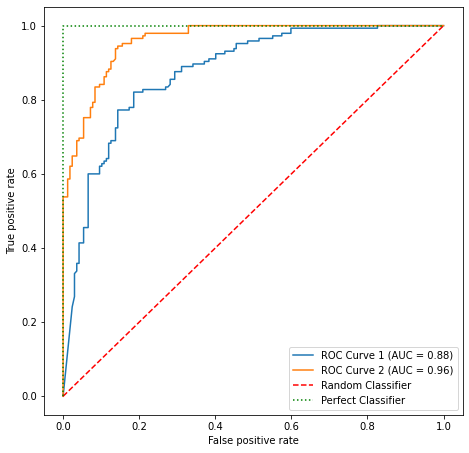

In [12]:
# from sklearn import datasets
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import roc_curve, auc
# import matplotlib.pyplot as plt
# from sklearn.pipeline import make_pipeline

# #Campare classification models
# probs = model.predict(x_test)
# fpr1, tpr1, thresholds = roc_curve(y_test, probs, pos_label=1)
# roc_auc1 = auc(fpr1, tpr1)

# probs2 = model2.predict(x_test)
# fpr2, tpr2, thresholds = roc_curve(y_test, probs2, pos_label=1)
# roc_auc2 = auc(fpr2, tpr2)
 
# fig, ax = plt.subplots(figsize=(7.5, 7.5))
 
# plt.plot(fpr1, tpr1, label='ROC Curve 1 (AUC = %0.2f)' % (roc_auc1))
# plt.plot(fpr2, tpr2, label='ROC Curve 2 (AUC = %0.2f)' % (roc_auc2))
# # plt.plot(fpr3, tpr3, label='ROC Curve 3 (AUC = %0.2f)' % (roc_auc3))
# plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Classifier')   
# plt.plot([0, 0, 1], [0, 1, 1], linestyle=':', color='green', label='Perfect Classifier')
# plt.xlim([-0.05, 1.05])
# plt.ylim([-0.05, 1.05])
# plt.xlabel('False positive rate')
# plt.ylabel('True positive rate')
# plt.legend(loc="lower right")
# plt.show()